# Atelier Préparation de Données Textuelles

 Contexte 
 
 Une entreprise souhaite développer un système capable de classer automatiquement des avis clients afin d'identifier leur sentiment. Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, réseaux sociaux et service client. Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes. Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent donc construire un pipeline complet de préparation des données textuelles. Objectifs pédagogiques À la fin de l'atelier, l'apprenant doit être capable de : 
 1) explorer un corpus textuel ; 
 2) identifier les problèmes de qualité des données ; 
 3) nettoyer les textes ; 
 4) tokeniser les textes ; 
 5) normaliser les données textuelles ; 
 6) transformer les textes en représentations numériques ; 
 7) comparer plusieurs méthodes de vectorisation ; 
 8) préparer un corpus exploitable par un modèle de ML/DL.

In [1]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  

# Partie 1 – Exploration du corpus

## 1) Charger les données CSV

In [2]:
df = pd.read_csv("../data/smart_reviews_raw.csv")  # charge le fichier CSV

df.head() 

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


## 2) Combien d'avis contient le dataset ?

In [3]:
print("2) Nombre d'avis :", len(df))  # nombre de lignes = nombre d'avis

2) Nombre d'avis : 1200


## 3) Combien de colonnes possède-t-il ?

In [4]:
print("3) Nombre de colonnes :", len(df.columns))  # nombre de colonnes

3) Nombre de colonnes : 8


## 4) Quel est le type de chaque colonne ?

In [5]:
print(df.dtypes)  # affiche le type de chaque colonne

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object


## 5) Existe-t-il des valeurs manquantes ?

In [6]:
print(df.isna().sum())  # compte les valeurs manquantes par colonne

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64


## 6) Identifier quelques types de texte

In [7]:
print("Texte normal :", df["texte"].iloc[3])
print("Texte vide :", df[df["texte"].str.strip() == ""]["texte"].head(1).tolist())
print("Avec URL :", df[df["texte"].str.contains("http", na=False)]["texte"].head(1).tolist())
print("Avec mention :", df[df["texte"].str.contains("@", na=False)]["texte"].head(1).tolist())
print("Avec hashtag :", df[df["texte"].str.contains("#", na=False)]["texte"].head(1).tolist())
print("Avec majuscules :", df[df["texte"].str.isupper()]["texte"].head(1).tolist())

Texte normal : Produit excellent, je suis très satisfait. !!!
Texte vide : ['   ']
Avec URL : ['Produit parfait, rien à signaler. https://example.com/commande/17']
Avec mention : ['@client Livraison rapide et produit conforme à mes attentes.']
Avec hashtag : ['Très satisfait de mon achat 👍 #avis']
Avec majuscules : ["LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."]


## 7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur »

###  cree une colonne avec le nombre de caracteres de chaque texte


In [8]:
df["longueur"] = df["texte"].str.len()  # cree une colonne avec le nombre de caracteres de chaque texte


### statistiques descriciptive de la longueur

In [9]:
print("Min :", df["longueur"].min())
print("Max :", df["longueur"].max())
print("Moyenne :", df["longueur"].mean())
print("Médiane :", df["longueur"].median())
print("Quartiles :", df["longueur"].quantile([0.25, 0.5, 0.75]))

Min : 2.0
Max : 636.0
Moyenne : 49.168200836820084
Médiane : 48.0
Quartiles : 0.25    37.0
0.50    48.0
0.75    56.0
Name: longueur, dtype: float64


## 8) Visualiser la distribution de la longueur des avis

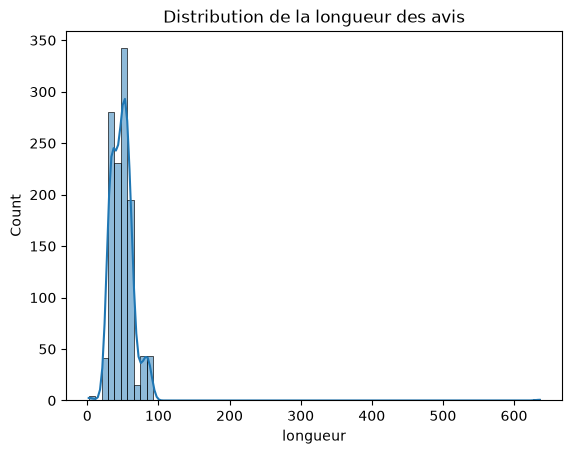

In [10]:
sns.histplot(df["longueur"].dropna(), kde=True)  # histogramme de la longueur des textes
plt.title("Distribution de la longueur des avis")
plt.show()

### a) Existe-t-il des textes anormalement longs ?


Oui — l'axe des x s'étend jusqu'à plus de 600 caractères, alors que la quasi-totalité des
avis se concentre entre 20 et 100. Cela indique la présence de quelques textes très longs,
statistiquement isolés, qui étirent l'échelle du graphique sans être visibles comme un
groupe : la masse principale
est resserrée, mais des valeurs extrêmes rares déforment l'axe).

### b) Existe-t-il beaucoup de textes très courts ?

Le pic principal se situe autour de 50-60 caractères, avec une remontée notable vers 20-30
également. Il n'y a pas de barre concentrée près de 0, donc pas une majorité de textes
"quasi vides" — mais une partie des avis reste courte (une phrase simple), cohérent avec
des avis clients typiques.

## 9) Détecter les textes vides

In [11]:
nb_vides = (df["texte"].str.strip() == "").sum()  # compte les textes reduits a rien une fois les espaces enleves
print("Textes vides :", nb_vides)

Textes vides : 1


## 10) Détecter les doublons sur le texte

In [12]:
nb_doublons = df["texte"].duplicated().sum()  # compte les textes identiques a un autre deja vu
print("Doublons :", nb_doublons)

Doublons : 881


## 11) Les classes sont-elles équilibrées ?

In [13]:
print(df["sentiment"].value_counts())

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64


non elle ne le sont pas 

## 12) Quelle est la classe majoritaire ?

In [14]:
print(df["sentiment"].value_counts(normalize=True) * 100)

sentiment
positif    64.666667
neutre     20.500000
negatif    14.833333
Name: proportion, dtype: float64


la classe positif est majoritaire   avec ~64%

## 13) Quelles métriques de classification à envisager d’utiliser ?

les classes sont désequilibrées, privilégier F1-score, precision,
recall par classe plutôt que l'accuracy seule (qui serait trompeuse).

## 14) Détecter les caractères particuliers :

### Emojis

In [15]:
print("Emojis (approx) :", df["texte"].str.contains(r'[\U0001F300-\U0001FAFF]', regex=True, na=False).sum())


Emojis (approx) : 192


### URLs

In [16]:
print("URLs :", df["texte"].str.contains(r'http\S+', regex=True, na=False).sum())


URLs : 143


###  Hashtags

In [17]:
print("Hashtags :", df["texte"].str.contains(r'#\w+', regex=True, na=False).sum())


Hashtags : 127


### Mentions

In [18]:
print("Mentions :", df["texte"].str.contains(r'@\w+', regex=True, na=False).sum())


Mentions : 128
